First 5 Rows
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  mathscore  readingscore  writingscore  
0                    none       72.0            72            74  
1               completed       69.0            90            88  
2                    none       90.0            95            93  
3                    none       47.0            57            44  
4                    none       76.0            78            75  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-

C:\Users\rudra\AppData\Local\Temp\ipykernel_1836\4168082400.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\rudra\AppData\Local\Temp\ipykernel_1836\4168082400.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

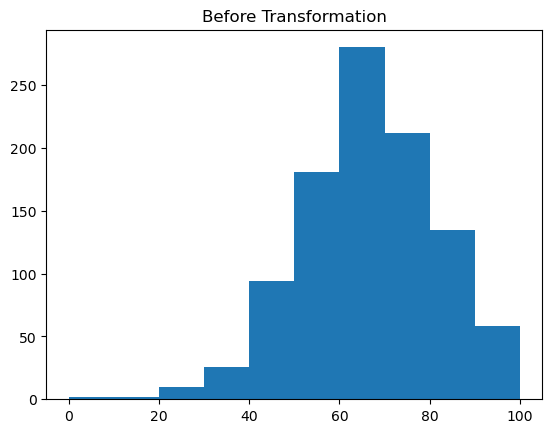

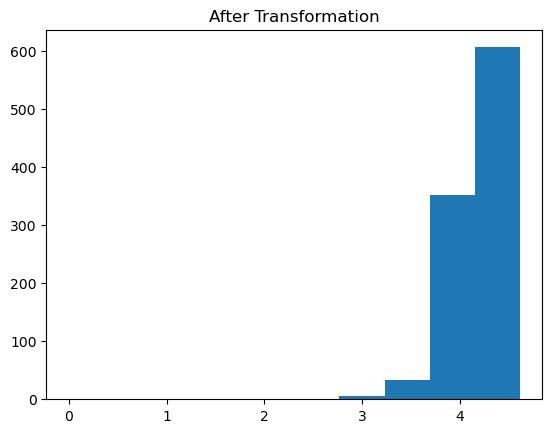

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:/Users/rudra/Downloads/StudentsPerformance.csv")

# Display dataset
print("First 5 Rows")
print(df.head())

# Dataset information
print("\nDataset Information")
print(df.info())

# Missing values
print("\nMissing Values")
print(df.isnull().sum())

# Handle missing values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove inconsistencies
for col in categorical_cols:
    df[col] = df[col].str.strip().str.lower()

# Skewness before transformation
print("\nSkewness Before Transformation")
print(df[numeric_cols].skew())

# Apply log transformation
df['math score log'] = np.log(df['mathscore'] + 1)

# Skewness after transformation
print("\nSkewness After Transformation")
print(df[['math score log']].skew())

# Histogram before transformation
plt.hist(df['mathscore'])
plt.title("Before Transformation")
plt.show()

# Histogram after transformation
plt.hist(df['math score log'])
plt.title("After Transformation")
plt.show()